**Install Meridian**

In [1]:
!pip install -U pip
!pip install google-meridian==1.4.0

**Data Ingestion**

Goal: Load and transform the data, and add necessary helper columns.

In [2]:
# Load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Read data
data = pd.read_csv("monthly_mocha.csv")

# Set datetime
data["date"] = pd.to_datetime(data["date"])

# Create constant
data["revenue_per_subscription"] = 100

# Cast all non-date columns to float
cols_to_float = data.columns.difference(["date"])
data[cols_to_float] = data[cols_to_float].astype("float64")

/tmp/ipython-input-4134320764.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["date"] = pd.to_datetime(data["date"])


**Structural Anomaly Detection**

Goal: Identify and resolve basic structural anomalies that would cause issues downstream.

In [3]:
# Check for null values
null_summary = data.isnull().sum().sort_values(ascending=False)
if sum(null_summary) == 0:
    print("Check passed - no null values.")
else:
    print(null_summary)

Check passed - no null values.


In [4]:
# Identify and remove constant predictors
helper = data.copy()
helper = helper.drop("revenue_per_subscription",axis=1) # preserve revenue constant
constant_cols = helper.columns[helper.nunique() <= 1].tolist()
if len(constant_cols) > 0:
    print("Check failed - columns with no variance. Dropped columns:")
    print(constant_cols)
    helper = helper.drop(constant_cols,axis=1)
else:
    print("Check passed - no constant columns.")
helper["revenue_per_subscription"] = data["revenue_per_subscription"] # add revenue back
data = helper

Check failed - columns with no variance. Dropped columns:
['roku_spend', 'roku_impressions']


In [5]:
# Identify and drop duplicates
duplicate_rows = data.duplicated().sum()
if duplicate_rows > 0:
    print("Duplicate rows exist. Dropped rows.")
    print(duplicate_rows)
    data = data.drop(duplicate_rows,axis=0)
else:
    print("Check passed - no duplicate rows.")

Check passed - no duplicate rows.


In [6]:
# Flag duplicate timestamps
duplicate_dates = data['date'].duplicated().sum()
if duplicate_dates > 0:
    print("Duplicate dates exist. Check accuracy and/or group.")
    print(duplicate_dates)
else:
    print("Check passed - no duplicate dates.")

Check passed - no duplicate dates.


**Exploratory Data Analysis**

Goal: Explore the data to identify patterns that may influence modeling methodology.

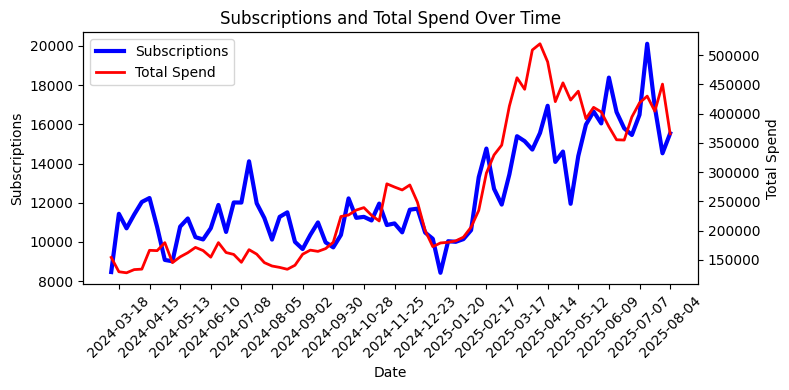

In [7]:
# Spend vs. KPI plot

# Calculate total spend
plt_data = data.copy()
spend_cols = plt_data.filter(like="spend").columns
plt_data["total_spend"] = plt_data[spend_cols].sum(axis=1)

# Initialize plot
plt.figure(figsize=(8, 4))

# Subscriptions
ax1 = plt.gca()
line_subs, = ax1.plot(
    plt_data["date"],
    plt_data["subscriptions"],
    linewidth=3,
    color="blue",
    label="Subscriptions"
)
ax1.set_title("Subscriptions and Total Spend Over Time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Subscriptions")

# Total Spend
ax2 = ax1.twinx()
line_spend, = ax2.plot(
    plt_data["date"],
    plt_data["total_spend"],
    linewidth=2,
    color="red",
    label="Total Spend"
)
ax2.set_ylabel("Total Spend")

# Clean axis test
idx = np.arange(0, len(plt_data), 4)
ax1.set_xticks(plt_data["date"].iloc[idx])
ax1.tick_params(axis="x", rotation=45)

# Merge legend
ax1.legend(handles=[line_subs, line_spend], loc="upper left")

# Plot
plt.tight_layout()
plt.show()

In [8]:
# Correlations

# Impressions and Subscriptions
imps_df = data.filter(regex=r"_impressions$")
corr_df = pd.concat([data[["subscriptions"]], imps_df], axis=1)

# Initialize matrix
corr = corr_df.corr()

# Extract pairs with high correlation (abs > 0.4)
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
        .rename(columns={
            "level_0": "Variable 1",
            "level_1": "Variable 2",
            0: "Correlation"
        })
        .query("abs(Correlation) > 0.4")
        .sort_values("Correlation", key=lambda s: s.abs(), ascending=False)
)

high_corr.reset_index(drop=True,inplace=True)
high_corr

,Variable 1,Variable 2,Correlation
0,subscriptions,beehiiv_impressions,0.849558
1,liveintent_impressions,beehiiv_impressions,0.700497
2,subscriptions,google_impressions,0.676619
3,google_impressions,beehiiv_impressions,0.644869
4,subscriptions,liveintent_impressions,0.625381
5,meta_impressions,liveintent_impressions,0.602293
6,snapchat_impressions,tiktok_impressions,-0.491776
7,moloco_impressions,beehiiv_impressions,0.423622
8,subscriptions,moloco_impressions,0.409659


In [9]:
# Impression variables
media_vars = data.filter(regex="_impressions$").columns.tolist()

# Calculate VIF
X = add_constant(data[media_vars])

vif = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif

,variable,VIF
0,const,23.376609
1,meta_impressions,1.804516
2,google_impressions,3.087581
3,snapchat_impressions,1.650744
4,tiktok_impressions,1.897792
5,moloco_impressions,1.743303
6,liveintent_impressions,3.722043
7,beehiiv_impressions,6.384323
8,amazon_impressions,1.091346


**Post-Hoc: Combine Channels**

Goal: Combine Beehiiv, LiveIntent, and Amazon into a "Below Threshold" channel to account for high VIF, correlations, and low spend.

In [10]:
below_threshold = ["liveintent","beehiiv","amazon"]  # Fill channel names

spend_cols = [f"{ch}_spend" for ch in below_threshold]
impression_cols = [f"{ch}_impressions" for ch in below_threshold]

# Calculate aggregate spend and impressions
data["below_threshold_spend"] = data[spend_cols].sum(axis=1)
data["below_threshold_impressions"] = data[impression_cols].sum(axis=1)

data = data.drop(columns=spend_cols + impression_cols) # drop old columns

# Calculate updated Spend Share for priors
spend_cols = data.filter(regex="_spend$").columns
spend_totals = data[spend_cols].sum() # total spend by channel
spend_share = spend_totals / spend_totals.sum() # share of spend by channel
print(spend_share)

meta_spend               0.043717
google_spend             0.535881
snapchat_spend           0.225957
tiktok_spend             0.091200
moloco_spend             0.043825
below_threshold_spend    0.059418
dtype: float64


**Modeling Dataset Creation**

Goal: Transform the data to pass it through Meridian's data_builder, and create seasonality variables based on EDA findings.

In [11]:
# Load packages
import meridian
from meridian.data import data_frame_input_data_builder as data_builder
from meridian.model import spec, prior_distribution
from meridian.model.model import Meridian
import tensorflow_probability as tfp
import tensorflow as tf

# Create new dataframe
df = data.copy()
df = df.rename(columns={'date': 'time'}) # Fix name for DataFrameBuilder
df = df.sort_values('time',ascending=True) # Proper handling of seasonality
df['time_idx'] = np.arange(len(df)) # Time index for seasonal variables

# Periodic variable creation
df['seasonal_sin'] = np.sin(2*np.pi*df['time_idx']/52)
df['seasonal_cos'] = np.cos(2*np.pi*df['time_idx']/52)

# Spike controls
df["july_spike"] = df["time"].isin(["2024-07-15", "2025-07-14"]).astype(int)

/tmp/ipython-input-1279612099.py:20: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["july_spike"] = df["time"].isin(["2024-07-15", "2025-07-14"]).astype(int)


In [12]:
# Extract channel list
channel_list = (
    df.filter(regex="_spend$")
      .columns
      .str.replace("_spend$", "", regex=True)
      .tolist()
)

# Meridian data builder
builder = data_builder.DataFrameInputDataBuilder(
    kpi_type='non_revenue',
    default_kpi_column="subscriptions",
    default_revenue_per_kpi_column="revenue_per_subscription",
)
builder = (
    builder
        .with_kpi(df)
        .with_revenue_per_kpi(df)
        .with_controls(df, control_cols=["seasonal_sin","seasonal_cos","july_spike"])
)
builder = builder.with_media(
    df,
    media_cols=[f"{channel}_impressions" for channel in channel_list],
    media_spend_cols=[f"{channel}_spend" for channel in channel_list],
    media_channels=channel_list,
)

data = builder.build()

**Calculate Priors**

Goal: Use EDA findings, 50% base assumption, and spend share to determine media Contribution priors and Random Effects prior.

In [13]:
# Contribution priors
mu = spend_share / 2  # spend share baseline
k_default = 70 # default confidence

# Manually override priors based on EDA
k_overrides = {
    "google_spend": 100,
    "below_threshold_spend": 100
}
k = mu.index.to_series().map(k_overrides).fillna(k_default).to_numpy()

# Calculate Beta parameters
alpha = (mu * k).to_numpy()
beta  = ((1 - mu) * k).to_numpy()

# Random Effects prior
mu_rf = 0.10
k_rf = 90

# Calculate Beta parameters
alpha_rf = (mu_rf * k_rf)
beta_rf  = ((1 - mu_rf) * k_rf)

In [14]:
# Generate table of priors

# Get Tactics
tactics = mu.index.str.replace("_spend$", "", regex=True)

# Build DataFrame
df_priors = pd.DataFrame({
    "tactic": tactics,
    "mu": mu.to_numpy(),
    "k": k,
    "alpha": alpha,
    "beta": beta,
}).set_index("tactic")

# Return table
print("Contribution priors:")
print(df_priors)

print("Random Effects priors:")
print(mu_rf,k_rf,alpha_rf,beta_rf)

Contribution priors:
                       mu      k      alpha       beta
tactic                                                
meta             0.021859   70.0   1.530107  68.469893
google           0.267941  100.0  26.794064  73.205936
snapchat         0.112979   70.0   7.908504  62.091496
tiktok           0.045600   70.0   3.192013  66.807987
moloco           0.021913   70.0   1.533889  68.466111
below_threshold  0.029709  100.0   2.970918  97.029082
Random Effects priors:
0.1 90 9.0 81.0


**Model Specifications**

Goal: Encode the final model specifications, including holdout_id and priors.

In [15]:
# Test/train holdout
np.random.seed(1)
test_pct = 0.1  # 10% holdout
n_geos = len(data.geo)
n_times = len(data.time)
new_holdout_id = np.full([n_geos, n_times], False)

for i in range(n_geos):
  new_holdout_id[
    i,
    np.random.choice(
      n_times,
      int(np.round(test_pct * n_times)),
    )
  ] = True

# Shape correction
corrected_holdout_id = new_holdout_id.flatten() if new_holdout_id.ndim > 1 else new_holdout_id

In [16]:
# Encode contribution and random effects priors
new_prior = prior_distribution.PriorDistribution(
    contribution_m=tfp.distributions.Beta(alpha.astype(np.float32), beta.astype(np.float32)),
    contribution_rf=tfp.distributions.Beta(alpha_rf, beta_rf),
)

# Define model specs
model_spec = spec.ModelSpec(
    prior=new_prior,
    media_effects_dist='log_normal',
    hill_before_adstock=False,
    max_lag=2, # Reflects assumption of short-term media patterns
    unique_sigma_for_each_geo=False,
    media_prior_type='contribution',
    roi_calibration_period=None, # None - using Contribution
    rf_prior_type='contribution',
    rf_roi_calibration_period=None, # None - using Contribution
    organic_media_prior_type='contribution',
    organic_rf_prior_type='contribution',
    non_media_treatments_prior_type='contribution',
    knots=2,
    baseline_geo=None,
    holdout_id=corrected_holdout_id,
    control_population_scaling_id=None,
    adstock_decay_spec='geometric',
    enable_aks=False,
)

**Model Run**

Goal: Run and store the model.

In [17]:
# Run the model
mmm = Meridian(input_data=data, model_spec=model_spec)
mmm.sample_prior(500)
mmm.sample_posterior(n_chains=7, n_adapt=100, n_burnin=500, n_keep=1000)

/usr/local/lib/python3.12/dist-packages/meridian/model/model.py:74: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1265: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-pa

**Model Diagnostics**

Goal: Calculate and examine model diagnostics, including convergence (R-hat), out-of-sample fit tests, and Actual v. Predicted plot.

In [18]:
# Load packages
from meridian.analysis import visualizer
from meridian.analysis import analyzer
import arviz as az

# R-hat boxplot
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.plot_rhat_boxplot()

alt.LayerChart(...)

In [19]:
# Prior and Posterior distributions
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.plot_prior_and_posterior_distribution('contribution_m')

alt.FacetChart(...)

In [20]:
# R-squared, MAPE, wMAPE
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.predictive_accuracy_table()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:629: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


,metric,geo_granularity,evaluation_set,value
0,R_Squared,national,Train,0.829569
1,R_Squared,national,Test,0.670670
2,R_Squared,national,All Data,0.820231
3,MAPE,national,Train,0.068282
4,MAPE,national,Test,0.079500
5,MAPE,national,All Data,0.069343
6,wMAPE,national,Train,0.066068
7,wMAPE,national,Test,0.078611
8,wMAPE,national,All Data,0.067255


In [21]:
# Expected v Actual Plots
model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:629: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


alt.LayerChart(...)

**Model Results Summary**

Goal: Generate a model results summary table and the visuals that appear in the PDF

In [22]:
media_summary = visualizer.MediaSummary(mmm)
media_summary.summary_table()

/usr/local/lib/python3.12/dist-packages/meridian/analysis/visualizer.py:1624: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,meta,prior,"192,617,568",20%,"$840,158",4%,$4,"$2,015,562 ($307,111, $4,730,463)","1.5% (0.2%, 3.4%)","2.4 (0.4, 5.6)","0.01 (0.00, 0.02)","1.2 (0.2, 3.1)","$54 ($18, $274)"
1,meta,posterior,"192,617,568",20%,"$840,158",4%,$4,"$1,819,045 ($649,796, $3,116,950)","2.0% (0.7%, 3.4%)","2.2 (0.8, 3.7)","0.01 (0.00, 0.02)","1.1 (0.3, 2.1)","$47 ($27, $129)"
2,google,prior,"460,146,496",47%,"$10,298,544",54%,$22,"$24,493,494 ($17,603,874, $31,710,706)","17.7% (12.8%, 23.0%)","2.4 (1.7, 3.1)","0.05 (0.04, 0.07)","1.0 (0.4, 1.6)","$43 ($32, $59)"
3,google,posterior,"460,146,496",47%,"$10,298,544",54%,$22,"$23,634,114 ($17,535,116, $30,260,334)","25.7% (19.1%, 32.9%)","2.3 (1.7, 2.9)","0.05 (0.04, 0.07)","0.9 (0.4, 1.3)","$44 ($34, $59)"
4,snapchat,prior,"200,407,408",20%,"$4,342,437",23%,$22,"$10,072,225 ($5,158,646, $15,852,802)","7.3% (3.7%, 11.5%)","2.3 (1.2, 3.7)","0.05 (0.03, 0.08)","1.1 (0.3, 2.1)","$44 ($27, $84)"
5,snapchat,posterior,"200,407,408",20%,"$4,342,437",23%,$22,"$10,181,110 ($5,463,349, $15,741,894)","11.1% (5.9%, 17.1%)","2.3 (1.3, 3.6)","0.05 (0.03, 0.08)","1.0 (0.4, 1.7)","$44 ($28, $79)"
6,tiktok,prior,"79,955,184",8%,"$1,752,685",9%,$22,"$4,201,927 ($1,398,841, $8,600,209)","3.0% (1.0%, 6.2%)","2.4 (0.8, 4.9)","0.05 (0.02, 0.11)","1.1 (0.3, 2.4)","$47 ($20, $125)"
7,tiktok,posterior,"79,955,184",8%,"$1,752,685",9%,$22,"$2,199,927 ($685,110, $4,259,903)","2.4% (0.7%, 4.6%)","1.3 (0.4, 2.4)","0.03 (0.01, 0.05)","0.6 (0.2, 1.3)","$86 ($41, $256)"
8,moloco,prior,"37,587,008",4%,"$842,235",4%,$22,"$1,944,714 ($254,604, $4,842,658)","1.4% (0.2%, 3.5%)","2.3 (0.3, 5.7)","0.05 (0.01, 0.13)","0.8 (0.1, 2.1)","$53 ($17, $331)"
9,moloco,posterior,"37,587,008",4%,"$842,235",4%,$22,"$2,930,229 ($539,148, $6,186,882)","3.2% (0.6%, 6.7%)","3.5 (0.6, 7.3)","0.08 (0.01, 0.16)","1.3 (0.2, 2.9)","$32 ($14, $156)"


In [23]:
media_summary.plot_channel_contribution_area_chart()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:3238: UserWarning: Effectiveness is not reported because it does not have a clear interpretation by time period.
  warnings.warn(


alt.Chart(...)

In [24]:
media_summary.plot_contribution_waterfall_chart()

alt.LayerChart(...)

In [25]:
media_summary.plot_spend_vs_contribution()

alt.FacetChart(...)

In [26]:
media_summary.plot_roi_bar_chart()

alt.LayerChart(...)

**Budget Optimization**

Goal: Optimize to KPI from historical spend allocation and generate the visuals in the PDF.

In [27]:
from meridian.analysis import optimizer

budget_optimizer = optimizer.BudgetOptimizer(mmm)

# Modeled channels
channels = ["meta", "google", "snapchat", "tiktok", "moloco", "below_threshold"]

# Pass historical spend shares through pct_of_spend
pct_of_spend = {ch: float(spend_share[f"{ch}_spend"]) for ch in channels}

# Calculate historical total spend (budget)
budget = df.filter(regex="_spend$").sum().sum()

# Adjust lower spend constraints
spend_constraint_lower = {
    "meta": 0.3,
    "google": 0.3,
    "snapchat": 0.3,
    "tiktok": 0.3,
    "moloco": 0.3,
    "below_threshold": 0.3,
}

# Adjust upper spend constraints
spend_constraint_upper = {
    "meta": 0.3,
    "google": 0.3,
    "snapchat": 0.3,
    "tiktok": 0.3,
    "moloco": 0.3,
    "below_threshold": 0.3,
}

build_channel_args = data.get_paid_media_channels_argument_builder()

optimization_results = budget_optimizer.optimize(
    selected_times=(df["time"].iloc[0], df["time"].iloc[-1]), # historical period
    budget= budget, # historical budget
    pct_of_spend=build_channel_args(**pct_of_spend), # historical allocation
    spend_constraint_lower=build_channel_args(**spend_constraint_lower),
    spend_constraint_upper=build_channel_args(**spend_constraint_upper),
)

/tmp/ipython-input-1282298195.py:36: DeprecationWarning: `selected_times` is deprecated. Please use `start_date` and `end_date` instead.
  optimization_results = budget_optimizer.optimize(


In [28]:
optimization_results.plot_spend_delta()

alt.LayerChart(...)

In [29]:
optimization_results.plot_incremental_outcome_delta()

alt.LayerChart(...)

In [30]:
optimization_results.plot_response_curves()

alt.FacetChart(...)